In [2]:
#Import important libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

In [5]:
import pandas as pd
# Loading dataset
train = pd.read_csv("englishtamilTrain.csv")

# Remove column only if it exists
train = train.drop(columns=["Unnamed: 0"], errors='ignore')

# Splitting English and Tamil columns
english_sentences = train["en"]
tamil_sentences = train["ta"]

# Selecting first 1000 rows
english_sentences = english_sentences.head(1000)
tamil_sentences = tamil_sentences.head(1000)

print(english_sentences.head())
print(tamil_sentences.head())

0               How are you?
1           I am learning AI
2    I love machine learning
3           See you tomorrow
4           Nice to meet you
Name: en, dtype: object
0                        ??????? ?????? ??????????????
1    ???? ??????? ?????????  ????????????? ???????????
2            ?????? ?????? ???????? ??????? ??????????
3                                     ???? ???????????
4                        ?????? ???????????? ?????????
Name: ta, dtype: object


In [6]:
#Importing word2vec, pca and pyplot for further process
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot

In [7]:
#Function for Spliting sentences
def sentToken(sentence):
    dataset = sentence
    sentences = [sentence.split() for sentence in dataset]
    print(sentences)
    return sentences

In [8]:
#calling sentence splitting function
engSentence=sentToken(english_sentences)

[['How', 'are', 'you?'], ['I', 'am', 'learning', 'AI'], ['I', 'love', 'machine', 'learning'], ['See', 'you', 'tomorrow'], ['Nice', 'to', 'meet', 'you'], ['Where', 'are', 'you', 'going?'], ['I', 'am', 'going', 'home'], ['I', 'live', 'in', 'Chennai'], ['This', 'is', 'my', 'friend'], ['Today', 'is', 'a', 'holiday'], ['I', 'like', 'music'], ['Artificial', 'Intelligence', 'is', 'amazing'], ['I', 'want', 'to', 'become', 'an', 'AI', 'engineer'], ['Natural', 'language', 'processing', 'is', 'fun'], ['The', 'weather', 'is', 'nice', 'today'], ['Python', 'is', 'easy', 'to', 'learn'], ['Success', 'comes', 'with', 'hard', 'work'], ['This', 'phone', 'is', 'expensive'], ['Turn', 'on', 'the', 'light']]


In [10]:
#calling sentence splitting function
taSentence=sentToken(tamil_sentences)

[['???????', '??????', '??????????????'], ['????', '???????', '?????????', '?????????????', '???????????'], ['??????', '??????', '????????', '???????', '??????????'], ['????', '???????????'], ['??????', '????????????', '?????????'], ['???????', '?????', '??????????????'], ['????', '??????????', '??????????'], ['????', '??????????', '???????????'], ['????', '???', '??????'], ['?????', '????????'], ['??????', '???', '??????????'], ['???????', '?????????', '???????????'], ['????', '???????', '?????????', '???????????', '????????'], ['??????', '????', '??????????', '?????????????'], ['??????', '??????', '???????', '??????'], ['??????', '????', '????????'], ['??????', '????', '?????????', '??????????'], ['????', '????????', '??????????????'], ['???????', '????????']]


In [11]:
#Creating word embedding model 
def ownWordModel(langsentence,modelname):
    from gensim.models import Word2Vec
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    model = Word2Vec(langsentence, min_count=1)
    print(model)
    # save model
    model.save(modelname)
    # fit a 2d PCA model to the vectors
    X = model.wv.vectors  # corrected line
    pca = PCA(n_components=2)
    result = pca.fit_transform(X)

    # create a scatter plot of the projection
    plt.scatter(result[:, 0], result[:, 1])
    words = list(model.wv.index_to_key)[:100]
    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    plt.show()

Word2Vec<vocab=60, vector_size=100, alpha=0.025>


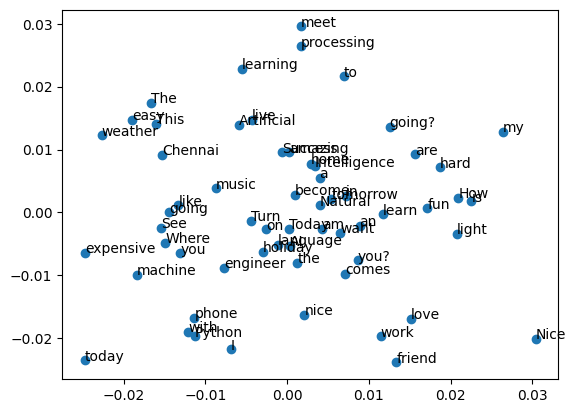

In [12]:
ownWordModel(engSentence,"englishmodel.bin")

Word2Vec<vocab=2, vector_size=100, alpha=0.025>


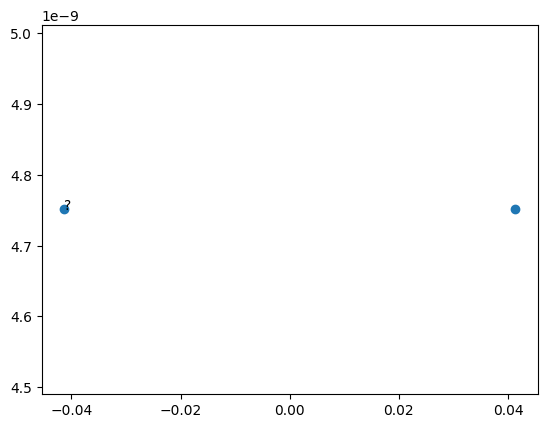

In [15]:
tamSentence = tamil_sentences
ownWordModel(tamSentence, "tamodel.bin")